# Financial Health Prediction

**Introduction** 
This is a ML challenge by Data.org on building models to assess the Financial Health Index of micro, small, and medium enterprises (MSMEs) across Southern Africa hosted by Zindi Africa.

**Aim**
The aim of this challenge is to assess the Financial Health Index of micro, small, and medium enterprises across 

**Obectives** 
 To classify businesses into Low, Medium, or High financial health across four key dimensions: savings and assests, debt and repayment, ability, resilience to shocks, and access to credit and financial services. 



## Imports and Setup

In [32]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
#importing the warnings library to ignore any warnings that may arise during the execution of the code
import warnings
#ignoring any warnings that may arise during the execution of the code
warnings.filterwarnings('ignore')   


## Data Loading 

In [33]:
train = pd.read_csv ('Train.csv')
test = pd.read_csv ('Test.csv')
variable_definitions = pd.read_csv ('VariableDefinitions.csv')

## Dataset Overview

Objectives

1. Checking the dataset dimensions. 
2. Checking  the number of features in the dataset. 
3. Checking the presents of the target variable. 

In [34]:
#data dimensions
print(f"The train dataset has dimensions: {train.shape[0]} by {train.shape[1]}")
print(f"\nThe test dataset has dimensions: {test.shape[0]} by {test.shape[1]}")
print(f"\nThe number of features in the train dataset is:{train.shape[1]}")
print(f"\nThe number of features in the test dataset is:{test.shape[1]}")

#check target variable
if 'Target' in train.columns and 'target' not in test.columns:
    print(f"\nTarget variable found in train set")
    print("Target variable correctly absent from test set")
else:
    print("Target variable not found in train set")



The train dataset has dimensions: 9618 by 39

The test dataset has dimensions: 2405 by 38

The number of features in the train dataset is:39

The number of features in the test dataset is:38

Target variable found in train set
Target variable correctly absent from test set


In [35]:
display(variable_definitions)

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


In [36]:
display(train.head(5))

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


In [37]:
display(test.head(5))


,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender
0,ID_5EGLKX,zimbabwe,50.0,No,No,No,No,Yes,100.0,3600.0,...,NaN,NaN,NaN,No,8.0,Never had,Never had,NaN,NaN,NaN
1,ID_4AI7RE,lesotho,36.0,Yes,Yes,No,Yes,Yes,900.0,400.0,...,NaN,NaN,NaN,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now
2,ID_V9OB3M,lesotho,25.0,Don’t know or N/A,No,No,Don't know,Don't know,5250.0,350.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,No,Never had,Used to have but don't have now
3,ID_6OI9DI,malawi,25.0,Don’t know or N/A,Yes,No,No,Yes,485000.0,10000.0,...,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,Have now,Never had
4,ID_H2TN8B,lesotho,47.0,No,Yes,No,Don't know,Don't know,97.0,500.0,...,Used to have but don't have now,Have now,Have now,Yes,NaN,NaN,NaN,Yes,Used to have but don't have now,Used to have but don't have now


# Target Variable Analysis
This section checks the distribution of the target variable to check for potential class imbalance. This is important when selecting the appropriate modelling and evaluation strategies. 

 Objectives: 
 1. To obtain the counts for each target class.
 2. To show the propotion of each class relative to the full data set. 

In [38]:
#counts of each target variable
print("Target Variable Analysis")
print("\nTarget Distibution")
print(train["Target"].value_counts())
print("\nTarget Percentage")
print(train["Target"].value_counts(normalize=True).sort_index().apply('{:.2%}'.format))

Target Variable Analysis

Target Distibution
Target
Low       6280
Medium    2868
High       470
Name: count, dtype: int64

Target Percentage
Target
High       4.89%
Low       65.29%
Medium    29.82%
Name: proportion, dtype: object


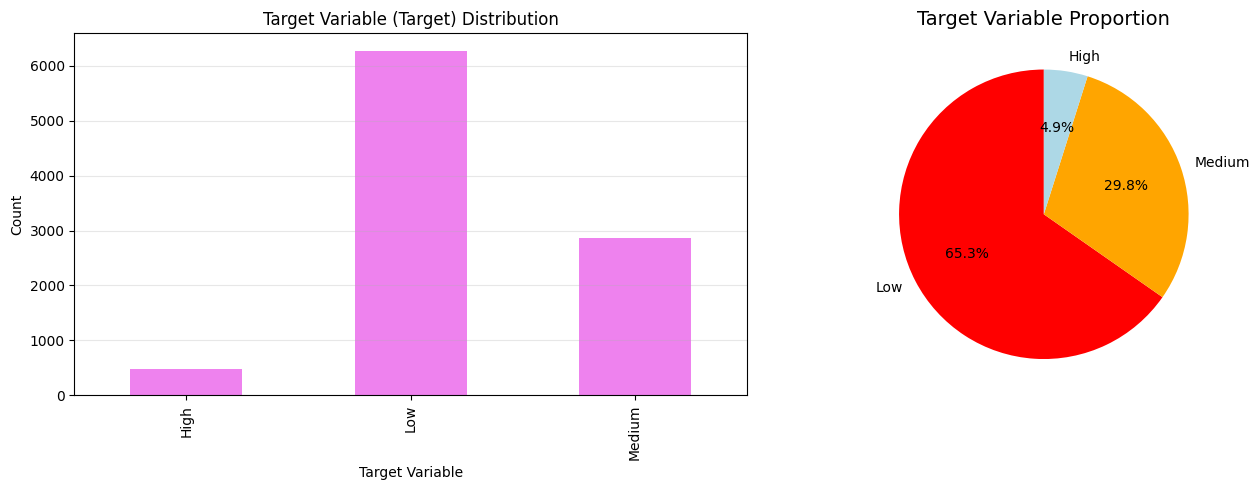


Class imbalance detected! Ratio: 13.36:1


In [39]:

#create a shell plot to visualize the target distribution. 
fig, axes = plt.subplots(1,2,figsize=(14,5))

#Count plot
train["Target"].value_counts().sort_index().plot(kind='bar', ax=axes[0], color="violet")
axes[0].set_title('Target Variable (Target) Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Target Variable')
axes[0].grid(axis='y', alpha=0.3)

t=train['Target'].value_counts()
axes[1].pie(t, labels= t.index,autopct='%1.1f%%',
            startangle=90, colors=['red', 'orange','lightblue'] )
axes[1].set_title('Target Variable Proportion', fontsize=14)

plt.tight_layout()
plt.show()

#check for class imbalance: 
class_ratio=train['Target'].value_counts().max()/train['Target'].value_counts().min()
if class_ratio > 1.5:
    print(f'\nClass imbalance detected! Ratio: {class_ratio:.2f}:1')
else: 
    print(f'Classes are relatively balanced. Ratio {class_ratio:.2f}:1')


## Dataset Information 

This section aims to provide a stucture overview of the training and testing datasets with the following objectives: 
1. To know the number of rows and columns in each dataset. 
2. To know and check if the columns match the varaible description. 
3. To know and correct for the data types of each feature. (Type casting).
4. To identify missing values, so that they can be handled accordingly. 



In [40]:
print("---TRAIN SET INFO---")
print(train.info())
print("---TEST SET INFO---")
print(test.info())

---TRAIN SET INFO---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9618 entries, 0 to 9617
Data columns (total 39 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ID                                                                9618 non-null   object 
 1   country                                                           9618 non-null   object 
 2   owner_age                                                         9618 non-null   float64
 3   attitude_stable_business_environment                              9616 non-null   object 
 4   attitude_worried_shutdown                                         9616 non-null   object 
 5   compliance_income_tax                                             9614 non-null   object 
 6   perception_insurance_doesnt_cover_losses                          9613 non-null   object 
 7   perception_c

## Missing Value Analysis
This section analyses missing data in both the training and test datasets, helping identify features that may rrequire imputation, transformation, or removal. 

Obectives: 
1. To calculate the number of missing values per column. 
2. To calculate the percentage of missing values relative to the dataset size. 
3. To filters and displays only columns that contain missing data. 
4. Sort columns by missing percentage. 

MISSING VALUE ANALYSIS

TRAIN SET - Columns with Missing Values
                                                         Columns  Missing_Count  Percentage
                                            uses_informal_lender           4489      46.673
                                     uses_friends_family_savings           4488      46.663
                                      motivation_make_more_money           4291      44.614
                                               funeral_insurance           4188      43.543
                                               medical_insurance           4188      43.543
                                             business_age_months           4111      42.743
                                         future_risk_theft_stock           4100      42.628
                                                  has_debit_card           4003      41.620
                                            has_internet_banking           4003      41.620
                

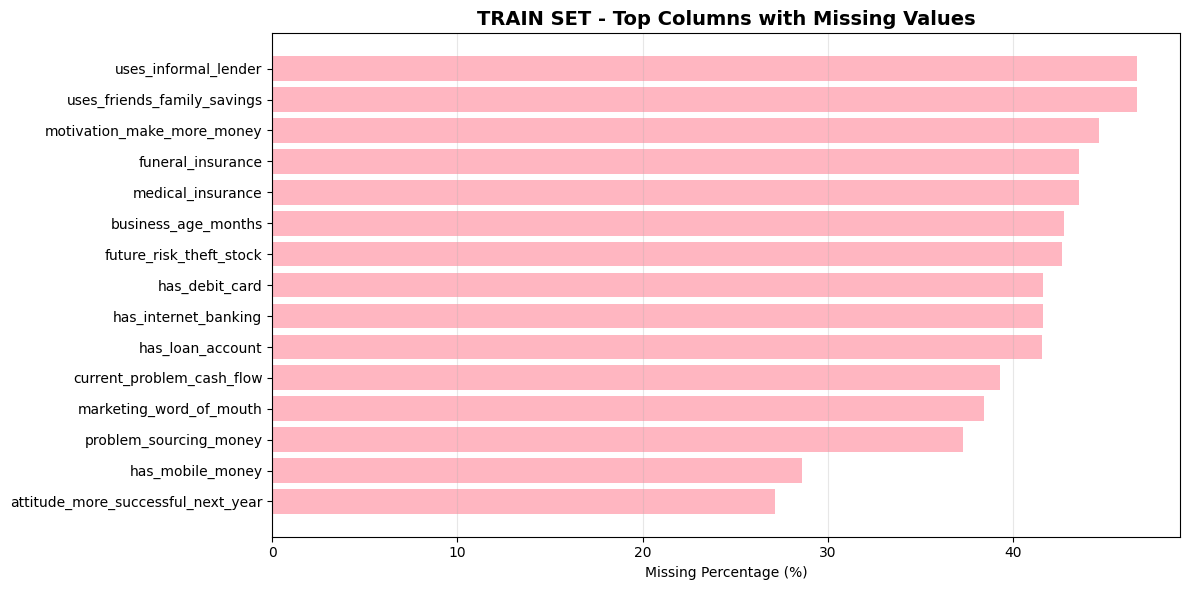


TEST SET - Columns with Missing Values
                                                         Columns  Missing_Count  Percentage
                                     uses_friends_family_savings           1131      47.027
                                            uses_informal_lender           1131      47.027
                                      motivation_make_more_money           1084      45.073
                                               funeral_insurance           1042      43.326
                                               medical_insurance           1042      43.326
                                             business_age_months           1033      42.952
                                         future_risk_theft_stock           1017      42.287
                                                  has_debit_card            992      41.247
                                                has_loan_account            992      41.247
                                        

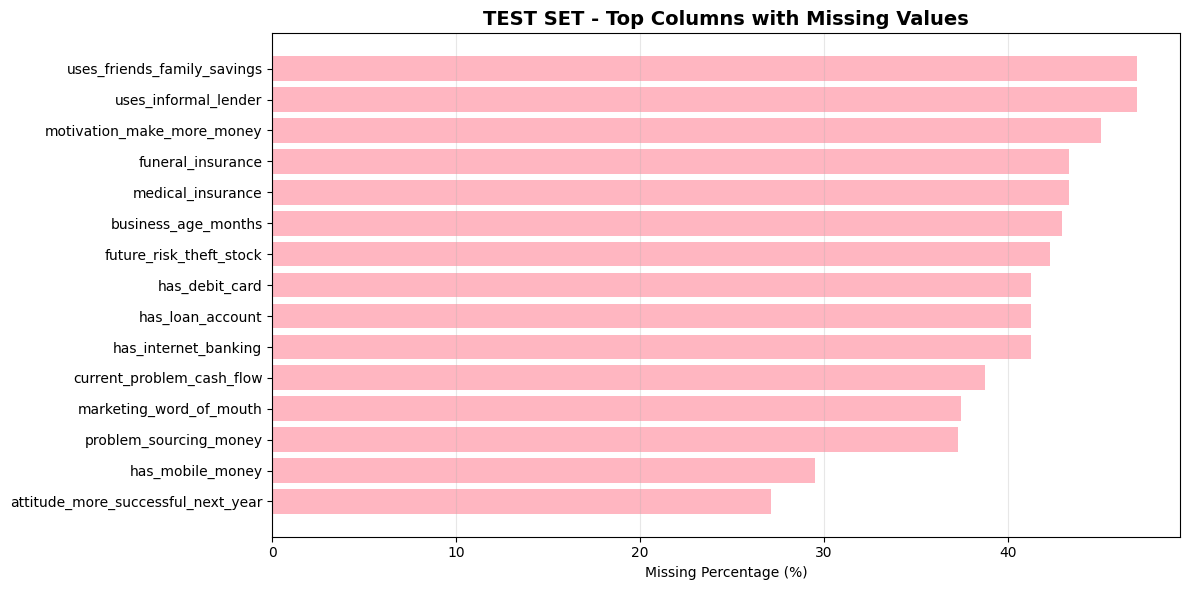

In [41]:

print('MISSING VALUE ANALYSIS')
print("=" * 60)

def analyse_missing(df,name): 
    #count the number of null in each column. 
    missing = df.isnull().sum() # train.isnull (True or False Train dataset on each entry.)
    #missing values percentage
    missing_pct = ((df.isnull().sum()/len(df))*100).round(3)
    # create a dataset that sorts the columns with missing values in descending order. 
    missing_dataframe = pd.DataFrame({
        'Columns': missing.index, 
        'Missing_Count': missing.values, 
        'Percentage': missing_pct.values
        }).query('Missing_Count>0').sort_values('Percentage',ascending= False)
    
    print(f"\n{name} - Columns with Missing Values")
    if len(missing_dataframe)>0: 
       # the dataset should have the following columns(column id, null count, percentage.)
       print(missing_dataframe.to_string(index=False))

       if len(missing_dataframe)>0:
            #plot a horizontal bar plot
            top_misssing =  missing_dataframe.head(15)
            plt.figure(figsize=(12,6))
            plt.barh(top_misssing["Columns"],top_misssing["Percentage"],color="lightpink")
            plt.xlabel("Missing Percentage (%)")
            plt.title(f"{name} - Top Columns with Missing Values", fontsize= 14, fontweight="bold")
            plt.gca().invert_yaxis()
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()  
    else:
        print("No missing values found!")

    return missing_dataframe

train_missing = analyse_missing(train,"TRAIN SET")
test_missing = analyse_missing(test,"TEST SET") 

## Numerical Features Analysis 

This section examines the numerical variables in the training set to understand their distribution, scales, and summary statistics. 

Objectives: 
1. To identify numerical features. 
2. To present summary statistics on these features.
3. To visualise selected key features.
 


NUMERICAL FEATURE ANALYSIS
------------------------------------------------------------
Numerical Features (6)
['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'business_age_months']

 Statistical Summary:
         owner_age  personal_income  business_expenses  business_turnover  \
count  9618.000000     9.509000e+03       9.389000e+03       9.402000e+03   
mean     41.705344     2.627345e+05       4.583838e+05       1.348210e+06   
std      13.314010     2.566268e+06       6.184746e+06       8.804741e+06   
min      18.000000     0.000000e+00       0.000000e+00       0.000000e+00   
25%      32.000000     3.000000e+02       7.000000e+02       1.500000e+03   
50%      40.000000     2.000000e+03       3.000000e+03       6.000000e+03   
75%      50.000000     2.500000e+04       2.500000e+04       5.000000e+04   
max     103.000000     1.500000e+08       5.000000e+08       4.200000e+08   

       business_age_years  business_age_months  
cou

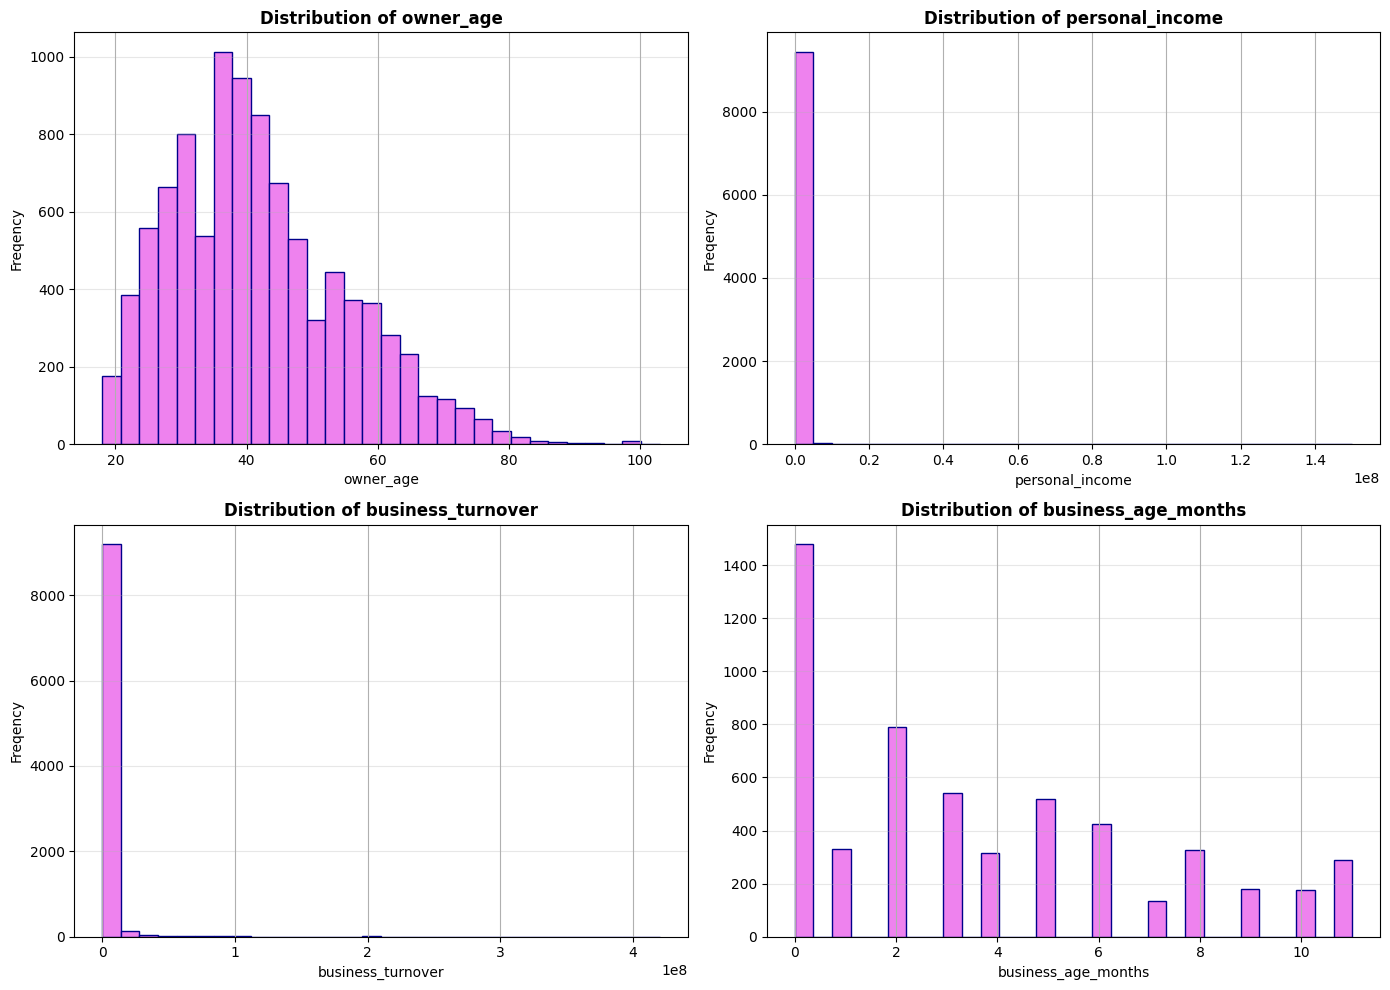

In [42]:

print("NUMERICAL FEATURE ANALYSIS")
print ("-"*60)
# identify numerical features 
numerical_cols=train.select_dtypes(include=['int64','float64']).columns.to_list()
# remove the target variable if it is present in the list of numerical features. 
if 'Target' in numerical_cols: 
    numerical_cols.remove('Target')

print (f"Numerical Features ({len(numerical_cols)})")
print (numerical_cols)

# present descriptive statistics on identified features. 
print("\n Statistical Summary:")
print(train[numerical_cols].describe())

# visualise selected key features. 
key_numerical = ['owner_age', 'personal_income','business_turnover','business_age_months' ]
available_numerical= [col for col in key_numerical if col in train.columns]

if available_numerical:
    fig, axes = plt.subplots(2, 2, figsize = (14,10))
    axes = axes.ravel()

    for idx, col in enumerate(available_numerical[:4]):
        train[col].hist(bins= 30, ax = axes[idx], color="violet", edgecolor="darkblue")
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel("Freqency")
        axes[idx].grid(axis='y',alpha= 0.3)

    plt.tight_layout()
    plt.show()






## Categorical Feature Analysis

This sections examines categorical variables in the training dataset, focusing on their quantity, variety, and uniqueness. 

Objectives: 
1. Identify categorical features. 
2. Identify the number of categorical variables in the training dataset. 
3. Display all the categorical variables and their cardinality. 



In [43]:
print("CATEGORICAL VARIABLE ANALYSIS")
print("-"*60)
#Select all variables with the data type = Object
cat_vars = train.select_dtypes(include="object").columns.to_list()
#remove ID from the list of categorical variables. 
if "ID" in cat_vars: 
    cat_vars.remove("ID")
# display the total number of categorical variables. 
print(f"\nCategorical Features({len(cat_vars)})")
print(cat_vars)

# Cardinality analysis. 
print("\n Cardinality (Unique Values) for Categorical Features:")
cardinality_df = pd.DataFrame({
    "Features": cat_vars,
    "Unique_values":[train[col].nunique() for col in cat_vars]}
).sort_values("Unique_values", ascending=False)
print(cardinality_df)


CATEGORICAL VARIABLE ANALYSIS
------------------------------------------------------------

Categorical Features(32)
['country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records', 'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important', 'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock', 'medical_insurance', 'funeral_insurance', 'motivation_make_more_money', 'uses_friends_family_savings', 'uses_informal_lender', 'Target']

 Cardinali

Country Distribution

This sections explores how observations are distributed across countries in both the training and testing datasets. 

------------------------------------------------------------
COUNTRY DISTRIBUTION
------------------------------------------------------------

Train Set Counrty Distribution:
country
eswatini    2674
zimbabwe    2612
malawi      2388
lesotho     1944
Name: count, dtype: int64

Test Set Country Distribution:
country
eswatini    669
zimbabwe    653
malawi      597
lesotho     486
Name: count, dtype: int64


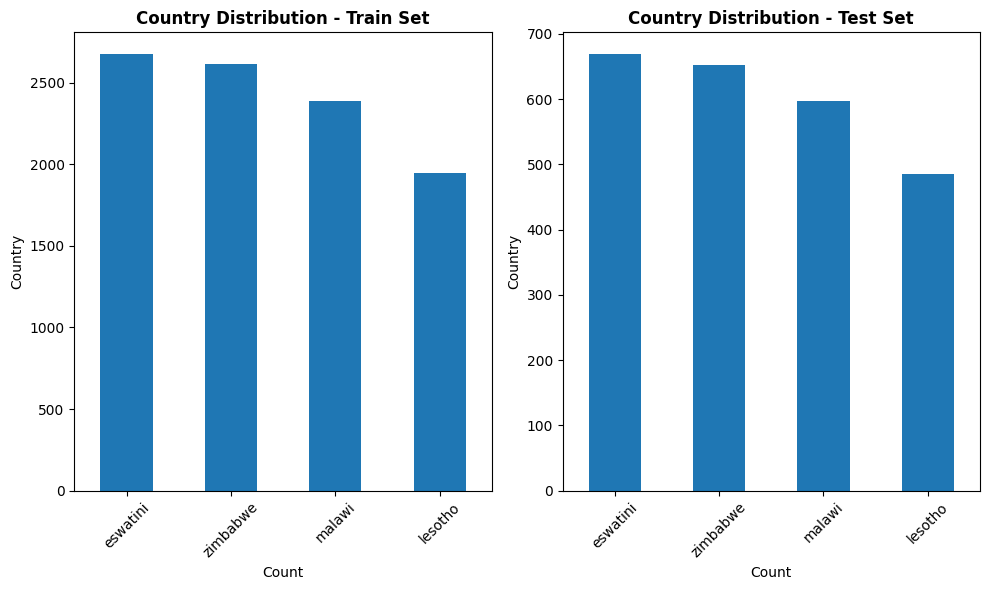

In [60]:
print("-"*60 )
print("COUNTRY DISTRIBUTION")
print('-'*60)
print("\nTrain Set Counrty Distribution:")
print (train["country"].value_counts())
print("\nTest Set Country Distribution:")
print(test["country"].value_counts())

fig, axes = plt.subplots(1,2,figsize =(10,6))

train["country"].value_counts().plot(kind="bar",ax=axes[0])
axes[0].set_title("Country Distribution - Train Set", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Country")
axes[0].set_xlabel("Count")
axes[0].tick_params(axis="x", rotation=45)

test['country'].value_counts().plot(kind="bar",ax=axes[1])
axes[1].set_title("Country Distribution - Test Set", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Country")
axes[1].set_xlabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()